In [51]:
# Data Preparation

import pandas as pd

fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [52]:
# Part 1: Data Exploration 
#Dataset Overview

fear.shape
fear.info()
fear.head()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


,timestamp,value,classification,date
0,1517463000,30,Fear,2/1/18
1,1517549400,15,Extreme Fear,2/2/18
2,1517635800,40,Fear,2/3/18
3,1517722200,24,Extreme Fear,2/4/18
4,1517808600,11,Extreme Fear,2/5/18


In [53]:
# Trading Dataset

trades.shape
trades.info()
trades.head()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2/12/24 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2/12/24 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2/12/24 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2/12/24 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2/12/24 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [54]:
# Check Missing Values

fear.isnull().sum()
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [55]:
# check duplicates

fear.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

In [56]:
trades = trades.drop_duplicates()
fear = fear.drop_duplicates()

In [57]:
# Convert Timestamps to Datetime

fear['date'] = pd.to_datetime(fear['date'])

/var/folders/vb/xk5v3nfj4njgtgxvdrp_clgr0000gn/T/ipykernel_1924/295416411.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fear['date'] = pd.to_datetime(fear['date'])


In [58]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

In [59]:
trades['date'] = trades['Timestamp'].dt.date
fear['date'] = fear['date'].dt.date

In [60]:
# Align the datasets by Date

merged = trades.merge(fear, on='date', how='left')

In [61]:
# Create Key Metricss

daily_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [62]:
# Win Rate
# create a new column 'win' to indicate whether the trade was profitable or not

trades['win'] = trades['Closed PnL'] > 0

In [63]:
win_rate = trades.groupby('Account')['win'].mean()

In [64]:
# Average Trade Size

avg_trade_size = trades['Size USD'].mean()

In [65]:
avg_trade_size_trader = trades.groupby('Account')['Size USD'].mean()

In [66]:
# Leverage Distribution

leverage_dist = trades['Size USD'].describe()

Text(0.5, 1.0, 'Trade Size Distribution')

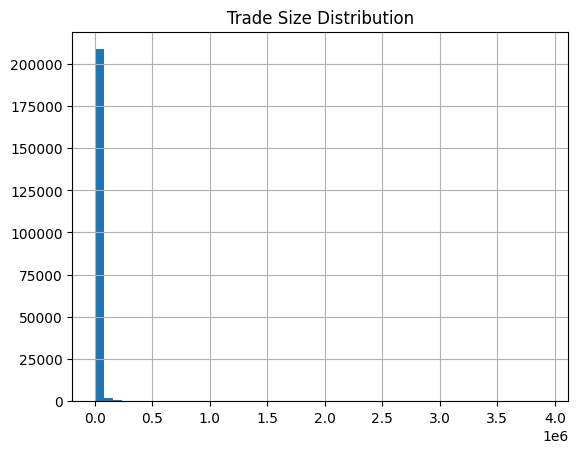

In [ ]:
# Histogram 

import matplotlib.pyplot as plt
trades['Size USD'].hist(bins=50)
plt.title("Trade Size Distribution")

In [77]:
# Number of Trades per Day

trades_per_day = trades.groupby('date').size()

In [78]:
# Long / Short Ratio
# Create indicator

long_short = trades['Side'].value_counts(normalize=True)

In [79]:
long_short_daily = trades.groupby(['date','Side']).size().unstack()

In [80]:
# Final Clean Dataset

final_dataset = trades.merge(fear, on='date', how='left')

In [81]:
# Part 2: Analysis 

#Goal: Understand how market sentiment (Fear vs Greed) affects trader performance and behavior.

# Dataset used:
# merged = trades + fear_greed_index


In [82]:
# Performance During Fear vs Greed

# Average PnL by Market Sentiment

sentiment_pnl = merged.groupby("classification")["Closed PnL"].mean()
print(sentiment_pnl)

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


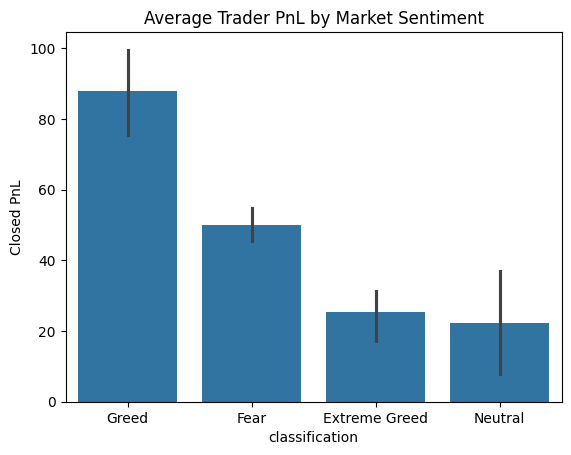

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x="classification", y="Closed PnL", data=merged)
plt.title("Average Trader PnL by Market Sentiment")
plt.show()

In [86]:
# win rate by sentiment

merged["win"] = merged["Closed PnL"] > 0

win_rate_sentiment = merged.groupby("classification")["win"].mean()
print(win_rate_sentiment)

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64


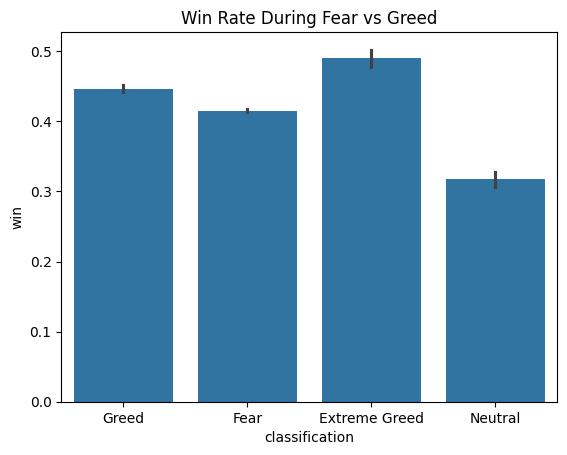

In [87]:
# visualization

sns.barplot(x="classification", y="win", data=merged)
plt.title("Win Rate During Fear vs Greed")
plt.show()

In [88]:
# Drawdown Analysis

drawdown = merged.groupby("classification")["Closed PnL"].min()
print(drawdown)

classification
Extreme Greed    -21524.40000
Fear             -35681.74723
Greed           -117990.10410
Neutral          -18360.67007
Name: Closed PnL, dtype: float64


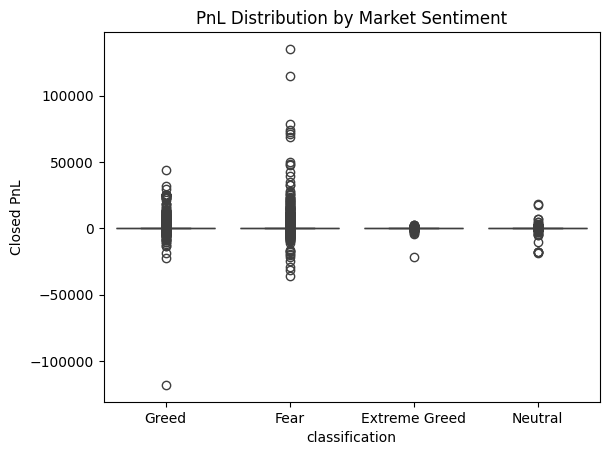

In [89]:
sns.boxplot(x="classification", y="Closed PnL", data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

In [90]:
# Trade behavior during different sentiments

trades_per_day = merged.groupby(["date","classification"]).size().reset_index(name="trades")

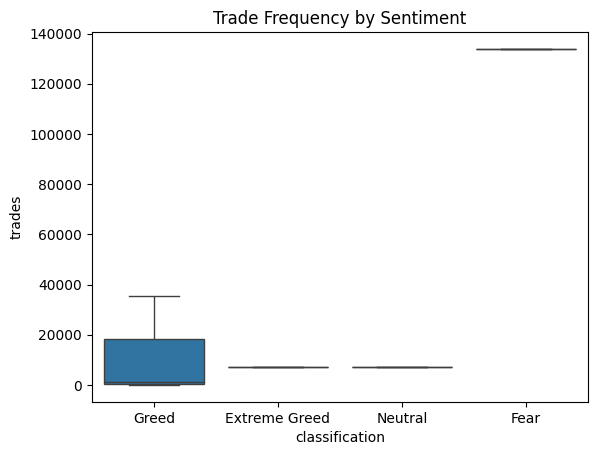

In [91]:
# visualization 

sns.boxplot(x="classification", y="trades", data=trades_per_day)
plt.title("Trade Frequency by Sentiment")
plt.show()

In [92]:
# postion size

position_size = merged.groupby("classification")["Size USD"].mean()
print(position_size)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


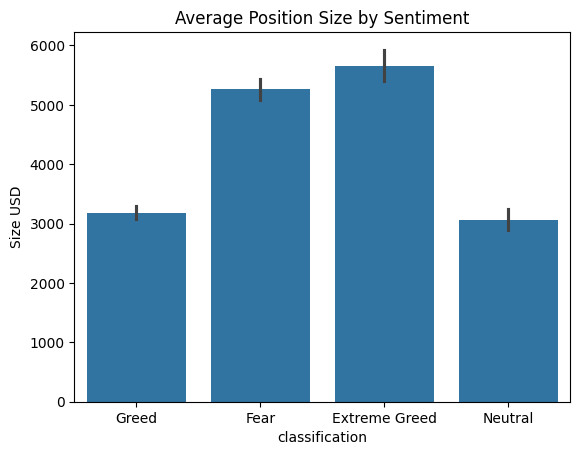

In [94]:
# Visualization
sns.barplot(x="classification", y="Size USD", data=merged)
plt.title("Average Position Size by Sentiment")
plt.show()

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


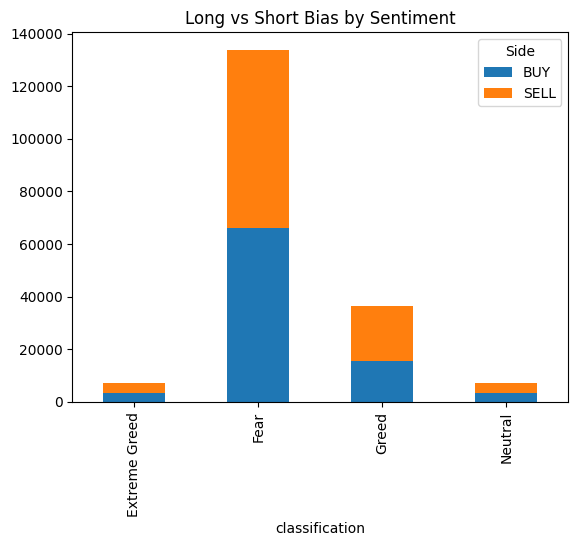

In [95]:
# long/ short bias
# visualization

long_short = merged.groupby(["classification","Side"]).size().unstack()
print(long_short)

long_short.plot(kind="bar", stacked=True)
plt.title("Long vs Short Bias by Sentiment")
plt.show()

In [96]:
# trade segmentation

# segment 1 high vs low leverage trades

merged["size_segment"] = pd.qcut(merged["Size USD"], 2, labels=["Low Size","High Size"])

In [97]:
#pnl commparison 

merged.groupby("size_segment")["Closed PnL"].mean()

size_segment
Low Size      4.381445
High Size    93.116556
Name: Closed PnL, dtype: float64

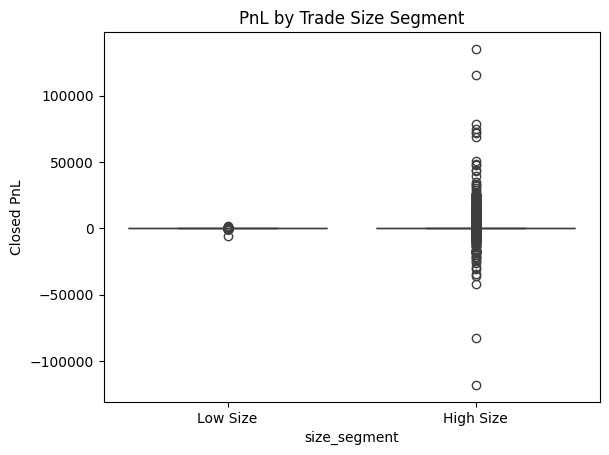

In [98]:
# Chart

sns.boxplot(x="size_segment", y="Closed PnL", data=merged)
plt.title("PnL by Trade Size Segment")
plt.show()

In [99]:
# Segment 2: frequent vs infrequent traders

# trade frequency per trader

trader_activity = merged.groupby("Account").size()

freq_segment = pd.qcut(trader_activity, 2, labels=["Infrequent","Frequent"])

In [ ]:
#Attach segment 

merged["activity_segment"] = merged["Account"].map(freq_segment)

In [ ]:
#Performance comparison

merged.groupby("activity_segment")["Closed PnL"].mean()

activity_segment
Infrequent    96.943024
Frequent      42.493421
Name: Closed PnL, dtype: float64

In [102]:
# Segment 3 consistent vs   inconsistent traders

# compute win rate per trader

trader_winrate = merged.groupby("Account")["win"].mean()

In [103]:
#Segment 

consistency = pd.qcut(trader_winrate, 2, labels=["Inconsistent","Consistent"])
merged["consistency_segment"] = merged["Account"].map(consistency)

In [104]:
#Performance 

merged.groupby("consistency_segment")["Closed PnL"].mean()

consistency_segment
Inconsistent    62.488537
Consistent      38.783637
Name: Closed PnL, dtype: float64

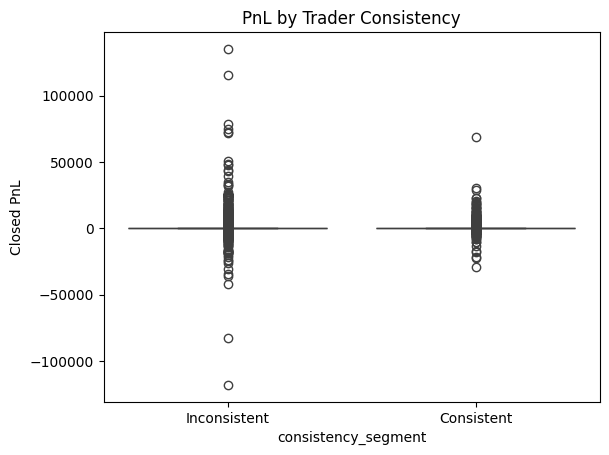

In [105]:
# Visualization

sns.boxplot(x="consistency_segment", y="Closed PnL", data=merged)
plt.title("PnL by Trader Consistency")
plt.show()

In [ ]:
#Project end 




Strategy Idea 1 — Be Defensive During Fear

When the market sentiment shifts toward Fear, trader performance tends to become more volatile. Losses increase and the probability of unsuccessful trades rises compared to Greed periods.

Rule of thumb

Reduce position sizes and leverage during Fear periods.
Focus on higher-quality setups instead of trading frequently.
This approach is particularly useful for high-leverage or aggressive traders, who tend to experience larger drawdowns during Fear phases.

Why this works

Fear periods often reflect uncertainty and rapid price swings. In such environments, preserving capital becomes more important than chasing short-term profits. Lower leverage helps traders survive volatility and avoid large losses.

Strategy Idea 2 — Take Advantage of Momentum During Greed

During Greed periods, traders generally show higher win rates and stronger average PnL. The market tends to move in clearer trends, which makes momentum strategies more effective.

Rule of thumb

Slightly increase trading activity when sentiment moves into Greed.
Traders with a history of consistent wins can cautiously increase position sizes to capture market momentum.
Maintain risk controls so that profits from trending markets are not erased by sudden reversals.

Why this works

Greed phases typically occur when market confidence is high and price movements follow stronger trends. Traders who already have a consistent track record can benefit from these conditions by scaling their trades moderately.